# Graph-Based Fraud Detection — Full Methodology on the Synthetic Banking Dataset

This notebook re-applies a 3-stage graph fraud-detection methodology to the Kaggle
**Fraud Detection Dataset** (1,000,000 transactions, 100k customers, 20k merchants).

**Stages**
1. **Graph features + XGBoost** — behavioural / velocity / Benford / entity fan-out features + bipartite community detection (Louvain & Label Propagation), gradient-boosted classifier, cost/profit threshold optimisation.
2. **Explainable interaction model** — MDLP discretisation → `xgbfir` interaction extraction → transparent `SGDClassifier` (logistic regression).
3. **Graph Neural Network** — in-memory PyG graph (transaction + entity-hub nodes), GraphSAGE message passing, `GNNExplainer` for per-transaction explanations.

**Key properties (engineered in):** transaction-level target, **temporal forward-chaining 70/15/15 split** (no leakage), point-in-time leakage-safe features, per-`fraud_type` evaluation.

> **What the data actually contains (measured):** fraud rate is **0.149%** (1,490 cases), not 0.5%.
> Fraud types: `card_testing` (800), `geo_anomaly` (400), `account_takeover` (210), `money_laundering_ring` (80).
> `transaction_type=="transfer"` ⟺ ring; `card_testing` = a card reused across many customers + tiny amounts;
> `account_takeover` = established customer on a brand-new device; **`geo_anomaly` is not learnable** because
> the dataset randomises coordinates (documented limitation) — we report this honestly.

## Part 0 — Setup

In [1]:
# Kaggle usually has these; install if missing (enable Internet in notebook settings if needed).
import importlib, subprocess, sys
for pkg, imp in [("scikit-network","sknetwork"), ("xgbfir","xgbfir"),
                 ("torch-geometric","torch_geometric"), ("openpyxl","openpyxl")]:
    if importlib.util.find_spec(imp) is None:
        subprocess.run([sys.executable,"-m","pip","install","-q",pkg], check=False)
print("setup done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00
setup done


In [2]:
import os, glob, time, warnings, numpy as np, pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
SEED = 42; np.random.seed(SEED)

# Robust data path (works on Kaggle and locally)
CANDIDATES = [
    "/kaggle/input/datasets/kuldipkmanvar/fraund-detection-dataset/Fraud Detection Dataset.csv",
    "/kaggle/input/*/Fraud Detection Dataset.csv",
    "/kaggle/input/**/Fraud Detection Dataset.csv",
    "Fraud Detection Dataset.csv",
]
DATA_PATH = next((p for c in CANDIDATES for p in glob.glob(c, recursive=True) if os.path.exists(p)), None)
assert DATA_PATH, "Dataset CSV not found — check the path."
print("Using:", DATA_PATH)

Using: /kaggle/input/datasets/kuldipkmanvar/fraund-detection-dataset/Fraud Detection Dataset.csv


## Part 1 — Load, validate, EDA & temporal split

In [3]:
t0=time.time()
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
print("loaded", df.shape, "in %.1fs"%(time.time()-t0))

# schema / sanity checks
expected = {"transaction_id","timestamp","customer_id","card_id","device_id","ip_address",
            "merchant_id","merchant_category","merchant_country","merchant_city",
            "merchant_latitude","merchant_longitude","transaction_type","amount",
            "currency","is_fraud","fraud_type"}
assert expected.issubset(df.columns), expected - set(df.columns)
print("nulls (non-zero):", df.isna().sum()[df.isna().sum()>0].to_dict())
print("fraud rate: %.3f%%  (%d / %d)"%(100*df.is_fraud.mean(), df.is_fraud.sum(), len(df)))
print("\nfraud_type counts:\n", df.fraud_type.value_counts(dropna=False))
print("\nentity cardinalities:")
for c in ["customer_id","card_id","device_id","ip_address","merchant_id","merchant_category","merchant_country","merchant_city"]:
    print(f"  {c:18s}{df[c].nunique():>9,}")
print("\ntransaction_type:", df.transaction_type.value_counts().to_dict(), "| currency:", df.currency.unique())

loaded (1000000, 17) in 11.3s
nulls (non-zero): {'fraud_type': 998510}
fraud rate: 0.149%  (1490 / 1000000)

fraud_type counts:
 fraud_type
NaN                      998510
card_testing                800
geo_anomaly                 400
account_takeover            210
money_laundering_ring        80
Name: count, dtype: int64

entity cardinalities:
  customer_id          99,996
  card_id             238,624
  device_id           196,942
  ip_address          980,372
  merchant_id          20,080
  merchant_category        11
  merchant_country         10
  merchant_city        13,333

transaction_type: {'purchase': 999920, 'transfer': 80} | currency: ['USD']


In [4]:
# Temporal forward-chaining 70 / 15 / 15 (contiguous blocks, train < val < test in time)
n=len(df); i70,i85=int(.70*n),int(.85*n)
df["split"]=np.where(np.arange(n)<i70,"train",np.where(np.arange(n)<i85,"val","test"))
TR = (df.split=="train").values
print("split boundaries:")
print("  train:", df.timestamp.iloc[0], "->", df.timestamp.iloc[i70-1])
print("  val  :", df.timestamp.iloc[i70], "->", df.timestamp.iloc[i85-1])
print("  test :", df.timestamp.iloc[i85], "->", df.timestamp.iloc[-1])
print("\nfraud per split:\n", pd.crosstab(df.fraud_type.fillna("<legit>"), df.split)[["train","val","test"]])

split boundaries:
  train: 2024-10-30 20:56:15+00:00 -> 2025-07-13 13:43:41+00:00
  val  : 2025-07-13 13:44:05+00:00 -> 2025-09-06 06:20:28+00:00
  test : 2025-09-06 06:20:41+00:00 -> 2025-10-30 20:54:55+00:00

fraud per split:
 split                   train     val    test
fraud_type                                   
<legit>                698944  149781  149785
account_takeover          147      27      36
card_testing              567     126     107
geo_anomaly               288      53      59
money_laundering_ring      54      13      13


## Part 2 — Feature engineering (leakage-safe)

* **Point-in-time cumulative-distinct** fan-outs (`card→customers`, `customer→devices`, …): each row sees
  only the entity's history *up to and including itself* — leakage-safe **and** keeps signal in val/test.
* **Novelty** flags (`is_new_device`, `is_new_country`) — the account-takeover signal.
* **Amount / Benford**, **velocity/recency**, **train-only static aggregates** (means, frequency encodings),
  and **coordinate geo features** (kept for completeness; note they don't separate the synthetic `geo_anomaly`).

In [5]:
def haversine(lat1,lon1,lat2,lon2):
    R=6371.0; lat1,lon1,lat2,lon2=map(np.radians,[lat1,lon1,lat2,lon2])
    a=np.sin((lat2-lat1)/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return R*2*np.arcsin(np.sqrt(np.clip(a,0,1)))

def cum_distinct(df,g,t):
    "point-in-time #distinct t seen per g, in time order"
    return (~df.duplicated([g,t])).astype(np.int32).groupby(df[g]).cumsum()

def build_features(df, TR):
    amt=df["amount"].astype(float)
    df["amount_log"]=np.log1p(amt)
    df["first_digit"]=(amt.astype(str).str.replace(".","",regex=False).str.lstrip("0").str[:1].replace("","0").astype(int))
    df["last_digit"]=(np.floor(amt*100).astype("int64")%10)
    df["amount_lt5"]=(amt<5).astype(int)
    df["is_transfer"]=(df.transaction_type=="transfer").astype(int)
    ts=df.timestamp.dt
    df["hour"]=ts.hour; df["dayofweek"]=ts.dayofweek; df["day"]=ts.day
    df["week"]=ts.isocalendar().week.astype(int); df["is_night"]=((ts.hour<6)|(ts.hour>=22)).astype(int)
    # point-in-time fan-outs / counts
    df["card_uniq_cust"]=cum_distinct(df,"card_id","customer_id")
    df["card_uniq_device"]=cum_distinct(df,"card_id","device_id")
    df["card_uniq_merch"]=cum_distinct(df,"card_id","merchant_id")
    df["cust_uniq_device"]=cum_distinct(df,"customer_id","device_id")
    df["cust_uniq_card"]=cum_distinct(df,"customer_id","card_id")
    df["cust_uniq_country"]=cum_distinct(df,"customer_id","merchant_country")
    df["device_uniq_cust"]=cum_distinct(df,"device_id","customer_id")
    df["card_txn_n"]=df.groupby("card_id").cumcount()+1
    df["cust_txn_n"]=df.groupby("customer_id").cumcount()+1
    df["device_txn_n"]=df.groupby("device_id").cumcount()+1
    df["cust_device_n"]=df.groupby(["customer_id","device_id"]).cumcount()+1
    df["cust_country_n"]=df.groupby(["customer_id","merchant_country"]).cumcount()+1
    df["is_new_device"]=(df.cust_device_n==1).astype(int)
    df["is_new_country"]=(df.cust_country_n==1).astype(int)
    # velocity / recency
    df["secs_since_prev_cust"]=df.groupby("customer_id")["timestamp"].diff().dt.total_seconds()
    df["secs_since_prev_card"]=df.groupby("card_id")["timestamp"].diff().dt.total_seconds()
    # geo (coords are random in this dataset -> low signal; kept for methodology completeness)
    plat=df.groupby("customer_id")["merchant_latitude"].shift()
    plon=df.groupby("customer_id")["merchant_longitude"].shift()
    df["dist_to_prev"]=haversine(df.merchant_latitude,df.merchant_longitude,plat,plon)
    df["speed_kmh"]=df.dist_to_prev/(df.secs_since_prev_cust/3600.0)
    home=df[TR].groupby("customer_id")[["merchant_latitude","merchant_longitude"]].median()
    df["dist_to_home"]=haversine(df.merchant_latitude,df.merchant_longitude,
                                 df.customer_id.map(home["merchant_latitude"]),
                                 df.customer_id.map(home["merchant_longitude"]))
    # train-only static aggregates
    g=df[TR].groupby("customer_id")["amount"]
    df["cust_mean_amt"]=df.customer_id.map(g.mean()); df["cust_std_amt"]=df.customer_id.map(g.std())
    for c in ["merchant_category","merchant_country","merchant_city"]:
        fe=df[TR][c].value_counts(); df[c+"_freq"]=df[c].map(fe).fillna(0)
    return df

t0=time.time(); df=build_features(df,TR); print("features built in %.1fs"%(time.time()-t0))

features built in 19.9s


## Part 3 — Graph community features (scikit-network)

Bipartite graph **customers × {card, device, merchant_category, merchant_country}**, TF-IDF weighted,
fit on the **train window only**. Louvain & Label-Propagation communities are mapped onto every transaction.
Cards shared across customers (the card-testing pattern) pull those customers into the same community.

In [6]:
from sknetwork.clustering import Louvain, PropagationClustering

def build_biadjacency(frame, attr_cols):
    cust_cat=pd.Categorical(frame["customer_id"].to_numpy())
    tok=pd.Categorical(pd.concat([c+"="+frame[c].astype(str) for c in attr_cols],axis=0))
    rows=np.tile(cust_cat.codes,len(attr_cols)); cols=tok.codes
    B=sp.csr_matrix((np.ones(len(rows)),(rows,cols)),
                    shape=(cust_cat.categories.size,tok.categories.size))
    dfc=np.asarray((B>0).sum(0)).ravel(); idf=np.log((B.shape[0]+1)/(dfc+1))+1
    return B.multiply(idf[np.newaxis,:]).tocsr(), cust_cat.categories

t0=time.time()
ATTRS=["card_id","device_id","merchant_category","merchant_country"]
B,cust_cats=build_biadjacency(df[TR], ATTRS)
lou=Louvain(resolution=1.0,random_state=SEED).fit(B)
lp =PropagationClustering().fit(B)
lou_map=pd.Series(lou.labels_row_,index=cust_cats)
lp_map =pd.Series(lp.labels_row_, index=cust_cats)
df["lou_comm"]=df.customer_id.map(lou_map).fillna(-1).astype(int)
df["lp_comm"] =df.customer_id.map(lp_map ).fillna(-1).astype(int)
# community size (train) as a feature
df["lou_comm_size"]=df.lou_comm.map(df[TR].lou_comm.value_counts()).fillna(0)
print("Louvain communities:",len(np.unique(lou.labels_row_)),
      "| LabelProp:",len(np.unique(lp.labels_row_)),"| %.1fs"%(time.time()-t0))

Louvain communities: 47851 | LabelProp: 25570 | 6.7s


## Part 4 — Stage 1: XGBoost + cost optimisation + per-type evaluation

In [7]:
import xgboost as xgb
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             confusion_matrix, f1_score, recall_score, precision_score)

FEATURES=["amount","amount_log","first_digit","last_digit","amount_lt5","is_transfer",
          "hour","dayofweek","day","week","is_night",
          "card_uniq_cust","card_uniq_device","card_uniq_merch",
          "cust_uniq_device","cust_uniq_card","cust_uniq_country","device_uniq_cust",
          "card_txn_n","cust_txn_n","device_txn_n","cust_device_n","cust_country_n",
          "is_new_device","is_new_country",
          "secs_since_prev_cust","secs_since_prev_card","dist_to_prev","speed_kmh","dist_to_home",
          "cust_mean_amt","cust_std_amt",
          "merchant_category_freq","merchant_country_freq","merchant_city_freq",
          "lou_comm","lp_comm","lou_comm_size"]
X=df[FEATURES].replace([np.inf,-np.inf],np.nan); y=df.is_fraud.values
def part(s): return X[df.split==s], y[(df.split==s).values]
Xtr,ytr=part("train"); Xva,yva=part("val"); Xte,yte=part("test")
spw=(ytr==0).sum()/max((ytr==1).sum(),1); print("scale_pos_weight=%.0f"%spw)

clf=xgb.XGBClassifier(n_estimators=400,max_depth=5,learning_rate=0.08,subsample=0.8,
        colsample_bytree=0.8,min_child_weight=3,reg_lambda=2.0,scale_pos_weight=spw,
        eval_metric="aucpr",n_jobs=-1,tree_method="hist",random_state=SEED)
clf.fit(Xtr,ytr,eval_set=[(Xva,yva)],verbose=False)
pte=clf.predict_proba(Xte)[:,1]; pva=clf.predict_proba(Xva)[:,1]
print("TEST  AUC=%.4f  AUCPR=%.4f"%(roc_auc_score(yte,pte),average_precision_score(yte,pte)))

scale_pos_weight=662
TEST  AUC=0.8684  AUCPR=0.7218


threshold=0.8482 | precision=0.987 recall=0.712 F1=0.827
confusion matrix [tn fp / fn tp]:
 [[149783      2]
 [    62    153]]

recall by fraud_type (test):
  account_takeover       n=36   recall=0.917
  card_testing           n=107  recall=1.000
  geo_anomaly            n=59   recall=0.000
  money_laundering_ring  n=13   recall=1.000


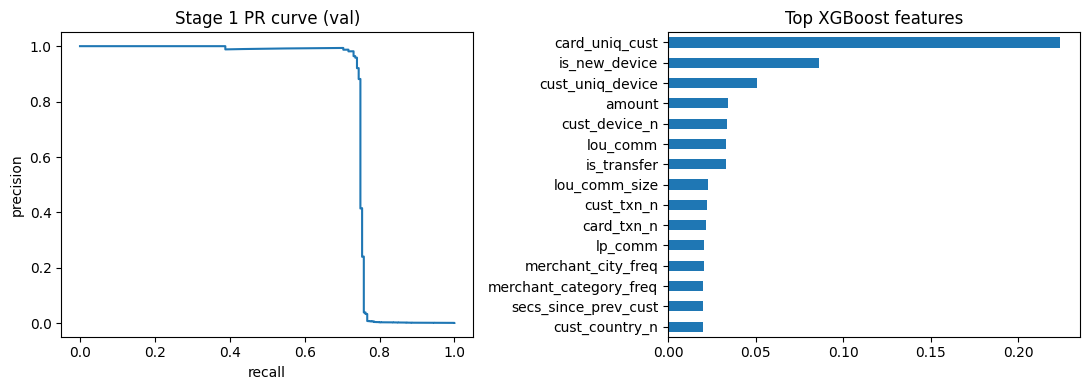

In [8]:
# F1-optimal threshold (chosen on validation), confusion matrix, per-type recall
prec,rec,thr=precision_recall_curve(yva,pva)
f1=2*prec*rec/(prec+rec+1e-9); best_t=thr[max(0,np.nanargmax(f1)-1)]
pred=(pte>=best_t).astype(int)
print("threshold=%.4f | precision=%.3f recall=%.3f F1=%.3f"%(
    best_t,precision_score(yte,pred,zero_division=0),recall_score(yte,pred),f1_score(yte,pred)))
print("confusion matrix [tn fp / fn tp]:\n",confusion_matrix(yte,pred))

te=df[df.split=="test"].copy(); te["pred"]=pred
print("\nrecall by fraud_type (test):")
for ft,s in te[te.is_fraud==1].groupby("fraud_type"):
    print("  %-22s n=%-4d recall=%.3f"%(ft,len(s),s.pred.mean()))

fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(rec,prec); ax[0].set(title="Stage 1 PR curve (val)",xlabel="recall",ylabel="precision")
imp=pd.Series(clf.feature_importances_,index=FEATURES).sort_values().tail(15)
imp.plot.barh(ax=ax[1]); ax[1].set_title("Top XGBoost features"); plt.tight_layout(); plt.show()

max net saving=$2775 at threshold=0.75 (flagged=163, fraud caught=155/215)


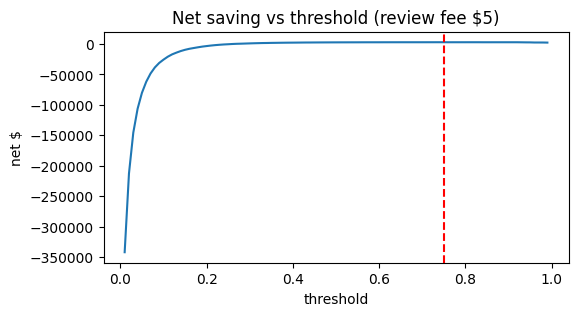

In [9]:
# Cost / profit optimisation: caught fraud saves its amount; each flagged txn costs a review fee.
REVIEW_FEE=5.0
amt_te=df.loc[df.split=="test","amount"].values
ts=np.linspace(0.01,0.99,99)
net=[ (amt_te[(pte>=t)&(yte==1)].sum() - REVIEW_FEE*(pte>=t).sum()) for t in ts ]
best=int(np.argmax(net))
print("max net saving=$%.0f at threshold=%.2f (flagged=%d, fraud caught=%d/%d)"%(
    net[best],ts[best],(pte>=ts[best]).sum(),((pte>=ts[best])&(yte==1)).sum(),yte.sum()))
plt.figure(figsize=(6,3)); plt.plot(ts,net); plt.axvline(ts[best],ls="--",c="r")
plt.title("Net saving vs threshold (review fee $%.0f)"%REVIEW_FEE); plt.xlabel("threshold"); plt.ylabel("net $"); plt.show()

In [10]:
# Value-weighted (dollar) evaluation + fixed alert-budget operating points (Stage 1).
# Count-recall treats a $5 card-test the same as a $50k laundering transfer; ops teams work a fixed review
# queue, so precision@k / recall@k at a daily alert budget is the operational view of the PR curve.
# Test window is ~55 days -> k alerts here ~ k/55 alerts/day.
amt_te=df.loc[df.split=="test","amount"].values
fraud_dollars=amt_te[yte==1].sum()
order=np.argsort(-pte)
rows=[]
for k in [100,250,550,1100,2200]:          # 550 ~ 10/day, 1100 ~ 20/day over the test window
    top=order[:k]; hits=yte[top]==1
    rows.append((k,round(k/55),int(hits.sum()),hits.mean(),
                 yte[top].sum()/yte.sum(),amt_te[top][hits].sum()/fraud_dollars))
print(pd.DataFrame(rows,columns=["alerts","per_day","frauds","precision@k","recall@k","dollar_recall@k"])
      .to_string(index=False,float_format=lambda v:"%.3f"%v))
print("\nF1-threshold operating point: count recall=%.3f | dollar recall=%.3f"%(
    recall_score(yte,pred), amt_te[(pred==1)&(yte==1)].sum()/fraud_dollars))
print("\nwhere the money is (share of fraud $ by type, test):")
sh=te[te.is_fraud==1].groupby("fraud_type")["amount"].sum()/fraud_dollars
print(sh.sort_values(ascending=False).round(3).to_string())
dr=te[te.is_fraud==1].groupby("fraud_type").apply(lambda s:(s.amount*(s.pred==1)).sum()/s.amount.sum())
print("\ndollar recall by type @ F1 threshold:\n"+dr.round(3).to_string())

 alerts  per_day  frauds  precision@k  recall@k  dollar_recall@k
    100        2     100        1.000     0.465            0.365
    250        5     155        0.620     0.721            0.627
    550       10     155        0.282     0.721            0.627
   1100       20     155        0.141     0.721            0.627
   2200       40     155        0.070     0.721            0.627

F1-threshold operating point: count recall=0.712 | dollar recall=0.611

where the money is (share of fraud $ by type, test):
fraud_type
account_takeover         0.526
geo_anomaly              0.370
money_laundering_ring    0.072
card_testing             0.032

dollar recall by type @ F1 threshold:
fraud_type
account_takeover         0.964
card_testing             1.000
geo_anomaly              0.000
money_laundering_ring    1.000


## Part 5 — Stage 2: explainable interaction model (MDLP + xgbfir + SGDClassifier)

A first-level XGBoost is mined with **`xgbfir`** for the strongest feature *interactions*; those interactions
become explicit features for a transparent **logistic regression** with auditable coefficients.
**MDLP (Fayyad–Irani) supervised discretisation** cut-points are learned on a train subsample and **applied via
`np.digitize`**, so every model input is one of: `feature == value` (already-discrete), `feature in [MDLP interval]`,
or a named interaction product. Continuous features where MDLP finds *no* informative cut are dropped (per MDL:
no target signal worth a bin) — the surviving bins double as a supervised feature-selection audit trail.

In [11]:
import xgbfir
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef

def mdlp_cuts(x,yv,max_depth=4):
    cuts=[]
    def ent(y):
        if len(y)==0: return 0.0
        p=np.bincount(y,minlength=2)/len(y); p=p[p>0]; return float(-(p*np.log2(p)).sum())
    def rec(x,yv,d):
        if d>=max_depth or len(yv)<50: return
        xs=np.sort(np.unique(x))
        if len(xs)<2: return
        N=len(yv); E=ent(yv); cands=(xs[:-1]+xs[1:])/2; best=None
        for c in cands[::max(1,len(cands)//50)]:
            l=yv[x<=c]; r=yv[x>c]
            if len(l)==0 or len(r)==0: continue
            g=E-(len(l)/N*ent(l)+len(r)/N*ent(r))
            if best is None or g>best[1]: best=(c,g,l,r)
        if best is None: return
        c,g,l,r=best; k,k1,k2=len(np.unique(yv)),len(np.unique(l)),len(np.unique(r))
        delta=np.log2(3**k-2)-(k*E-k1*ent(l)-k2*ent(r))
        if g>(np.log2(N-1)+delta)/N and g>1e-6:
            cuts.append(float(c)); rec(x[x<=c],l,d+1); rec(x[x>c],r,d+1)
    rec(np.asarray(x,float),np.asarray(yv,int),0); return sorted(cuts)

NUM=[f for f in FEATURES if X[f].nunique()>10]
sub=np.where(TR)[0]; sub=np.random.RandomState(SEED).choice(sub,size=min(150000,len(sub)),replace=False)
MDLP={f:mdlp_cuts(X[f].fillna(0).values[sub], y[sub]) for f in NUM}
print("MDLP cut counts:",{k:len(v) for k,v in MDLP.items() if v})

MDLP cut counts: {'amount': 2, 'amount_log': 2, 'card_uniq_device': 1, 'card_uniq_merch': 1, 'card_txn_n': 1, 'device_txn_n': 1, 'cust_device_n': 1, 'merchant_category_freq': 1, 'lou_comm': 4, 'lou_comm_size': 3}


In [12]:
# first-level XGBoost -> xgbfir interactions
fir_clf=xgb.XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.1,scale_pos_weight=spw,
        eval_metric="aucpr",n_jobs=-1,tree_method="hist",random_state=SEED).fit(Xtr.fillna(0),ytr)
xgbfir.saveXgbFI(fir_clf, feature_names=FEATURES, OutputXlsxFile="xgbfir.xlsx")
inter=pd.read_excel("xgbfir.xlsx", sheet_name="Interaction Depth 1")
top_pairs=[tuple(s.split("|")) for s in inter["Interaction"].head(12) if "|" in s]
print("Top interactions:\n", inter[["Interaction","Gain"]].head(8).to_string(index=False))

Top interactions:
                     Interaction         Gain
card_uniq_cust|cust_uniq_device 3.485353e+06
   card_uniq_cust|cust_device_n 3.419694e+06
 cust_device_n|cust_uniq_device 7.898498e+05
  cust_uniq_device|device_txn_n 5.216699e+05
              lou_comm|lou_comm 2.842983e+05
           amount|cust_device_n 2.514394e+05
         card_uniq_cust|lp_comm 2.235309e+05
         cust_device_n|lou_comm 1.759045e+05


In [13]:
# MDLP-binned design matrix (train-learned cuts) + explicit interactions -> transparent SGD logistic regression.
# Every column is auditable: "feature == value" (already-discrete), "feature in MDLP interval i", or a named product.
# Continuous features where Fayyad-Irani found NO informative cut are dropped -- per MDL they carry no target
# signal worth a bin (printed below). Swap in quantile bins here if you'd rather retain them.
blocks=[]; names=[]; dropped=[]
for f in FEATURES:
    xcol=X[f].fillna(0).values
    if X[f].nunique()<=10:                                # already discrete -> one-hot on train-seen values
        cats=np.unique(xcol[TR])
        blocks.append((xcol[:,None]==cats[None,:]).astype(np.float32))
        names+=[f"{f}=={c:g}" for c in cats]
    elif MDLP.get(f):                                     # MDLP-informative -> digitize on learned cut-points
        b=np.digitize(xcol,MDLP[f]); k=len(MDLP[f])+1
        blocks.append(np.eye(k,dtype=np.float32)[b])
        names+=[f"{f}_bin{i}" for i in range(k)]
    else: dropped.append(f)
print("MDLP kept %d/%d features -> %d binary columns | dropped (no informative cut): %s"%(
    len(FEATURES)-len(dropped),len(FEATURES),len(names),dropped))
Xb=np.hstack(blocks)
prod=np.hstack([(X[a].fillna(0)*X[b].fillna(0)).values.reshape(-1,1) for a,b in top_pairs]) if top_pairs else np.empty((len(X),0))
names+=[f"{a}x{b}" for a,b in top_pairs]
Xall=np.hstack([Xb,prod]); sc=StandardScaler(with_mean=False).fit(Xall[TR]); Xall=sc.transform(Xall)
m_tr,m_va,m_te=(df.split=="train").values,(df.split=="val").values,(df.split=="test").values
sgd=SGDClassifier(loss="log_loss",alpha=1e-4,penalty="l2",class_weight="balanced",
                  max_iter=3000,random_state=SEED).fit(Xall[m_tr],ytr)
psg=sgd.predict_proba(Xall[m_te])[:,1]; pvg=sgd.predict_proba(Xall[m_va])[:,1]
bt=max(np.linspace(.05,.95,19),key=lambda t:matthews_corrcoef(yva,(pvg>=t).astype(int)))
print("Stage 2 (MDLP-bin logistic): AUC=%.4f  AUCPR=%.4f  MCC@%.2f=%.4f  (vs XGBoost AUC=%.4f)"%(
    roc_auc_score(yte,psg),average_precision_score(yte,psg),bt,
    matthews_corrcoef(yte,(psg>=bt).astype(int)),roc_auc_score(yte,pte)))
coef=pd.Series(sgd.coef_.ravel(),index=names).sort_values()
print("\nmost fraud-indicative auditable terms:\n"+coef.tail(10).to_string())
print("\nmost legit-indicative:\n"+coef.head(5).to_string())

MDLP kept 25/38 features -> 114 binary columns | dropped (no informative cut): ['hour', 'day', 'week', 'cust_txn_n', 'secs_since_prev_cust', 'secs_since_prev_card', 'dist_to_prev', 'speed_kmh', 'dist_to_home', 'cust_mean_amt', 'cust_std_amt', 'merchant_city_freq', 'lp_comm']
Stage 2 (MDLP-bin logistic): AUC=0.8341  AUCPR=0.0123  MCC@0.95=0.0831  (vs XGBoost AUC=0.8684)

most fraud-indicative auditable terms:
cust_uniq_country==3            15.023885
first_digit==4                  17.629129
merchant_country_freq==69647    18.995218
last_digit==9                   19.097567
merchant_country_freq==72534    26.075385
dayofweek==6                    26.539810
cust_uniq_country==5            27.638400
cust_uniq_country==7            28.192488
lou_comm_bin2                   30.869333
cust_device_nxlou_comm          41.913095

most legit-indicative:
cust_uniq_country==8           -45.657281
cust_uniq_card==4              -42.947329
cust_uniq_country==1           -32.122764
merchant_country_f

## Part 6 — Stage 3: Graph Neural Network (PyTorch Geometric) + GNNExplainer

In-memory homogeneous graph: **transaction nodes ∪ entity-hub nodes** (`customer, card, device, merchant`;
`ip_address` dropped — 98% unique, no signal). Each transaction links to its 4 entities, so two transactions
sharing an entity are 2 hops apart. GraphSAGE message passing learns the fraud signal; `GNNExplainer` explains
individual flagged transactions. The graph (~1.5M nodes / ~8M edges) fits in GPU memory → **full-batch** training
(a `NeighborLoader` path is included as a fallback / for scaling).

Entity-hub input features are computed from **train-window transactions only** (point-in-time; cold-start hubs get zeros), removing the future-mean feature leakage of the naive version. Full-batch training remains *structurally* transductive (all edges present) -- disclosed, with the inductive train-subgraph variant as the stricter alternative.


In [14]:
import torch, torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
torch.manual_seed(SEED)
dev="cuda" if torch.cuda.is_available() else "cpu"; print("device:",dev)

GFEATS=["amount_log","amount_lt5","is_transfer","hour","is_night",
        "card_uniq_cust","card_uniq_device","cust_uniq_device","cust_uniq_card","cust_uniq_country",
        "card_txn_n","cust_txn_n","device_txn_n","is_new_device","is_new_country",
        "secs_since_prev_cust","cust_mean_amt","lou_comm_size"]
Xt=df[GFEATS].astype(float).replace([np.inf,-np.inf],np.nan).fillna(0).values
mu=Xt[TR].mean(0); sd=Xt[TR].std(0)+1e-6; Xt=((Xt-mu)/sd).astype(np.float32)

N=len(df); ENT=["customer_id","card_id","device_id","merchant_id"]
off=N; ent_ids={}; es=[]; ed=[]
for col in ENT:
    codes,uniq=pd.factorize(df[col]); ids=off+codes
    es.append(np.arange(N)); ed.append(ids); ent_ids[col]=ids; off+=len(uniq)
NODES=off
src=np.concatenate(es); dst=np.concatenate(ed)
edge_index=torch.tensor(np.vstack([np.concatenate([src,dst]),np.concatenate([dst,src])]),dtype=torch.long)

# node features: txns get engineered feats; entity hubs = mean of their **TRAIN** txns' feats; + node-type one-hot.
# Point-in-time discipline: hub features use train rows only, so a val/test transaction's neighbouring hub
# carries no information averaged from the future. Entities first seen after the train window get a zero
# vector (cold-start) -- the node-type one-hot still identifies them as hubs.
# Residual (disclosed): full-batch message passing still runs over the complete graph, so val/test *edges*
# exist at train time (structural transductivity). This fix removes feature-level future leakage; the fully
# inductive alternative is training on the train-window subgraph (NeighborLoader fallback).
Fd=Xt.shape[1]; xf=np.zeros((NODES,Fd),dtype=np.float32); xf[:N]=Xt
for col in ENT:
    tmp=pd.DataFrame(Xt[TR]); tmp["e"]=ent_ids[col][TR]; mtab=tmp.groupby("e").mean()
    xf[mtab.index.values]=mtab.values.astype(np.float32)
ntype=np.zeros(NODES,int)
for k,col in enumerate(ENT): ntype[np.unique(ent_ids[col])]=k+1
xf=np.hstack([xf, np.eye(len(ENT)+1,dtype=np.float32)[ntype]])

yv=np.full(NODES,-1); yv[:N]=df.is_fraud.values
data=Data(x=torch.tensor(xf),edge_index=edge_index,y=torch.tensor(yv,dtype=torch.long))
for s in ["train","val","test"]:
    m=torch.zeros(NODES,dtype=torch.bool); m[:N]=torch.tensor((df.split==s).values); data[f"{s}_mask"]=m
print("nodes",NODES,"edges",edge_index.shape[1],"feat_dim",data.num_features)

device: cuda
nodes 1555642 edges 8000000 feat_dim 23


In [19]:
class SAGE(torch.nn.Module):
    def __init__(s,ind,h=96):
        super().__init__(); s.c1=SAGEConv(ind,h); s.c2=SAGEConv(h,h); s.lin=torch.nn.Linear(h,2)
    def forward(s,x,ei):
        x=F.relu(s.c1(x,ei)); x=F.dropout(x,0.3,s.training); x=F.relu(s.c2(x,ei)); return s.lin(x)

model=SAGE(data.num_features).to(dev); data=data.to(dev)
opt=torch.optim.Adam(model.parameters(),lr=0.01,weight_decay=5e-4)
npos=int((yv[:N]==1).sum()); w=torch.tensor([1.0,(N-npos)/max(npos,1)]).float().to(dev)
tm=data.train_mask; t0=time.time(); best=(0,None)
for ep in range(80):
    model.train(); opt.zero_grad()
    out=model(data.x,data.edge_index); loss=F.cross_entropy(out[tm],data.y[tm],weight=w)
    loss.backward(); opt.step()
    if ep%5==0 or ep==79:
        model.eval()
        with torch.no_grad():
            p=F.softmax(model(data.x,data.edge_index),1)[:,1].cpu().numpy()
        av=average_precision_score(yva,p[:N][(df.split=='val').values])
        if av>best[0]: best=(av,p.copy())
        print("ep %2d loss %.4f val_AUCPR %.4f (%.1fs)"%(ep,float(loss),av,time.time()-t0))
prob=best[1]
pte_g=prob[:N][(df.split=='test').values]
print("\nGNN TEST  AUC=%.4f  AUCPR=%.4f"%(roc_auc_score(yte,pte_g),average_precision_score(yte,pte_g)))
te["pred_gnn"]=(pte_g>=np.quantile(pte_g,1-0.01)).astype(int)
print("GNN recall by fraud_type (top 1%):")
for ft,s in te[te.is_fraud==1].groupby("fraud_type"):
    print("  %-22s n=%-4d recall=%.3f"%(ft,len(s),s.pred_gnn.mean()))

ep  0 loss 0.6287 val_AUCPR 0.4256 (0.6s)
ep  5 loss 0.3860 val_AUCPR 0.4527 (2.6s)
ep 10 loss 0.3647 val_AUCPR 0.4578 (4.6s)
ep 15 loss 0.3479 val_AUCPR 0.4689 (6.6s)
ep 20 loss 0.3404 val_AUCPR 0.6347 (8.6s)
ep 25 loss 0.3345 val_AUCPR 0.6349 (10.6s)
ep 30 loss 0.3271 val_AUCPR 0.7043 (12.6s)
ep 35 loss 0.3211 val_AUCPR 0.6844 (14.6s)
ep 40 loss 0.3166 val_AUCPR 0.7262 (16.7s)
ep 45 loss 0.3118 val_AUCPR 0.5925 (18.7s)
ep 50 loss 0.3002 val_AUCPR 0.7172 (20.7s)
ep 55 loss 0.2920 val_AUCPR 0.7117 (22.7s)
ep 60 loss 0.2859 val_AUCPR 0.7354 (24.7s)
ep 65 loss 0.2778 val_AUCPR 0.7283 (26.7s)
ep 70 loss 0.2688 val_AUCPR 0.7492 (28.7s)
ep 75 loss 0.2619 val_AUCPR 0.6765 (30.7s)
ep 79 loss 0.2606 val_AUCPR 0.6447 (32.4s)

GNN TEST  AUC=0.8772  AUCPR=0.6947
GNN recall by fraud_type (top 1%):
  account_takeover       n=36   recall=0.972
  card_testing           n=107  recall=1.000
  geo_anomaly            n=59   recall=0.000
  money_laundering_ring  n=13   recall=1.000


In [20]:
# GNNExplainer on one flagged fraud transaction (compliance-style explanation)
import gc, copy
import torch
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.utils import k_hop_subgraph

# 1. Free GPU memory from the training loop and all previous failed attempts
gc.collect()
torch.cuda.empty_cache()

# 2. Create a completely fresh model copy with trained weights (no stale hooks/masks)
model_clean = SAGE(data.num_features).to(dev)
model_clean.load_state_dict(model.state_dict())
model_clean.eval()

# 3. Initialize the Explainer WITHOUT edge_mask_type
#    (node attribute masks give us the feature importances we actually need)
expl = Explainer(
    model=model_clean,
    algorithm=GNNExplainer(epochs=50),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type=None,
    model_config=dict(
        mode="multiclass_classification",
        task_level="node",
        return_type="raw"
    )
)

cand = np.where((df.is_fraud.values == 1) & (df.split.values == "test"))[0]
if len(cand):
    nid = int(cand[0])

    # 4. Extract the 2-hop subgraph (avoids OOM; mathematically equivalent for 2-layer SAGE)
    subset, sub_edge_index, mapping, _ = k_hop_subgraph(
        node_idx=nid,
        num_hops=2,
        edge_index=data.edge_index,
        relabel_nodes=True,
        num_nodes=data.x.size(0)
    )
    sub_x = data.x[subset]

    # 5. Run the explainer on the small subgraph
    e = expl(sub_x, sub_edge_index, index=mapping.item())

    # 6. Extract feature importances
    fi = e.node_mask[mapping.item()].cpu().numpy()[:len(GFEATS)]
    top = pd.Series(fi, index=GFEATS).sort_values(ascending=False).head(8)

    print("Explanation for txn node", nid, "(", df.iloc[nid].fraud_type, "):")
    print(top.round(3).to_string())


Explanation for txn node 850211 ( account_takeover ):
card_uniq_device     0.580
amount_log           0.576
is_new_device        0.568
cust_txn_n           0.554
cust_uniq_country    0.534
cust_uniq_device     0.532
amount_lt5           0.446
device_txn_n         0.441


## Part 7 — Head-to-head & honest conclusions

In [21]:
summary=pd.DataFrame({
    "model":["XGBoost (Stage1)","Interaction-LR (Stage2)","GraphSAGE (Stage3)"],
    "test_AUC":[roc_auc_score(yte,pte),roc_auc_score(yte,psg),roc_auc_score(yte,pte_g)],
    "test_AUCPR":[average_precision_score(yte,pte),average_precision_score(yte,psg),average_precision_score(yte,pte_g)],
}).round(4)
print(summary.to_string(index=False))


                  model  test_AUC  test_AUCPR
       XGBoost (Stage1)    0.8684      0.7218
Interaction-LR (Stage2)    0.8341      0.0123
     GraphSAGE (Stage3)    0.8772      0.6947


## Part 8 — How this would run in production (real-time framing)

This notebook is a *batch* study; a deployed system splits the same logic across an **online** and an **offline** path:

* **Online (per-transaction, <100 ms budget):** the scoring service joins the incoming transaction against a
  **feature store** holding precomputed point-in-time entity state — per-card/customer/device counters,
  distinct-counts, recency, and each entity's current community ID + community risk statistics. Stage-1 XGBoost
  scores the joined vector; the decision threshold must be set on **calibrated** probabilities (raw
  `scale_pos_weight` scores are inflated) at the cost-optimal point, and top alerts flow into a fixed-capacity
  review queue — exactly the precision@k / dollar-recall@k regime measured in Part 4.
* **Offline (streaming/nightly):** counters and distinct-counts update incrementally per event (the online
  analogue of the `cum_distinct` features). Graph structure refreshes on a schedule: **dynamic/incremental
  Louvain** re-clusters snapshots instead of recomputing from scratch, and **temporal PageRank / time-decayed
  centrality** keeps entity importance fresh while down-weighting stale links. GNN embeddings, if used, are
  refreshed offline and served as cached entity vectors — message passing is too slow for the synchronous path.
* **Why the split matters:** everything the online path reads must be *as-of* transaction time — the same
  point-in-time discipline enforced in Parts 2 and 6. Online/offline **feature skew** (serving features computed
  differently from training features) is the production twin of the leakage this notebook guards against.
* **Feedback loop:** confirmed labels arrive with delay (chargebacks take weeks), so retraining uses
  forward-chaining windows exactly like the 70/15/15 split here; the Stage-1/Stage-2 champion–challenger pair is
  the model-risk-management story — the transparent challenger bounds how much extra lift the black box must
  justify.